# 🏆 Gold Price Prediction using Machine Learning
### With K-Fold & Time-Series Cross-Validation

This notebook builds an end-to-end machine learning pipeline to predict daily
gold prices (USD/oz) using macroeconomic indicators such as the US Dollar Index,
interest rates, inflation, crude oil prices, the S&P 500, VIX volatility index,
and more.

**Pipeline stages:**
1. Data loading & exploration
2. Exploratory Data Analysis (EDA) & correlation analysis
3. Feature engineering (lag features, moving averages, volatility)
4. Train/test split (chronological, since this is time-series data)
5. Model training: Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting, XGBoost, SVR
6. **Cross-validation**: both `KFold` and `TimeSeriesSplit` — and a discussion of why they disagree
7. Model evaluation (MAE, RMSE, R²)
8. Feature importance analysis
9. Saving the final model (`.pkl`) for deployment in the Streamlit app


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"


## 1. Load the Dataset

In [2]:
df = pd.read_csv("gold_price_data.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Dataset shape: (3621, 17)
Date range: 2015-02-11 to 2028-12-27


,Date,Gold_Price_USD,Silver_Price_USD,Crude_Oil_USD,USD_Index,SP500_Index,Inflation_Rate_%,Interest_Rate_%,VIX_Volatility_Index,USD_INR_Rate,Gold_ETF_Holdings_Tonnes,Gold_Trading_Volume,Gold_Price_Lag1,Gold_Price_Lag7,Gold_MA_7,Gold_MA_30,Gold_Volatility_7
0,2015-02-11,1096.59,20.83,54.69,93.59,1995.38,1.16,0.64,22.66,64.81,761.24,266.74,1091.53,1101.74,1095.040000,1102.548000,3.159378
1,2015-02-12,1092.31,18.79,53.48,93.73,2008.58,1.13,0.63,22.28,64.71,762.82,265.24,1096.59,1095.38,1094.601429,1102.530333,3.313631
2,2015-02-13,1089.15,19.25,54.55,93.83,2000.31,1.09,0.64,23.07,64.84,763.76,292.62,1092.31,1100.77,1092.941429,1102.273333,2.525156
3,2015-02-16,1099.86,20.45,54.07,93.54,1989.94,1.07,0.64,22.01,64.87,767.49,345.23,1089.15,1091.72,1094.104286,1102.046667,3.539481
4,2015-02-17,1083.39,19.64,53.94,94.02,1980.77,0.98,0.62,22.45,65.02,774.55,264.40,1099.86,1095.31,1092.401429,1101.315333,5.294835


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3621 entries, 0 to 3620
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      3621 non-null   datetime64[us]
 1   Gold_Price_USD            3621 non-null   float64       
 2   Silver_Price_USD          3621 non-null   float64       
 3   Crude_Oil_USD             3621 non-null   float64       
 4   USD_Index                 3621 non-null   float64       
 5   SP500_Index               3621 non-null   float64       
 6   Inflation_Rate_%          3621 non-null   float64       
 7   Interest_Rate_%           3621 non-null   float64       
 8   VIX_Volatility_Index      3621 non-null   float64       
 9   USD_INR_Rate              3621 non-null   float64       
 10  Gold_ETF_Holdings_Tonnes  3621 non-null   float64       
 11  Gold_Trading_Volume       3621 non-null   float64       
 12  Gold_Price_Lag1           3621 

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,3621,2022-01-19 00:00:00,2015-02-11 00:00:00,2018-08-01 00:00:00,2022-01-19 00:00:00,2025-07-09 00:00:00,2028-12-27 00:00:00,NaN
Gold_Price_USD,3621.0,1363.409102,1083.39,1272.7,1360.43,1460.86,1653.81,127.98557
Silver_Price_USD,3621.0,23.054275,18.17,21.88,23.11,24.3,28.17,1.70848
Crude_Oil_USD,3621.0,72.429014,33.18,61.18,74.37,84.76,109.48,17.676078
USD_Index,3621.0,94.193811,88.54,92.38,94.0,95.6,101.88,2.645808
SP500_Index,3621.0,3930.140613,1937.41,2617.02,4101.51,5058.9,5500.0,1178.284822
Inflation_Rate_%,3621.0,1.371892,-0.5,0.67,1.39,2.0,3.96,1.012045
Interest_Rate_%,3621.0,2.480817,0.62,2.11,2.5,2.88,4.12,0.762315
VIX_Volatility_Index,3621.0,25.979525,9.0,18.45,25.69,33.0,53.67,11.105465
USD_INR_Rate,3621.0,82.023195,64.71,78.35,83.63,88.0,88.0,6.600864


## 2. Exploratory Data Analysis

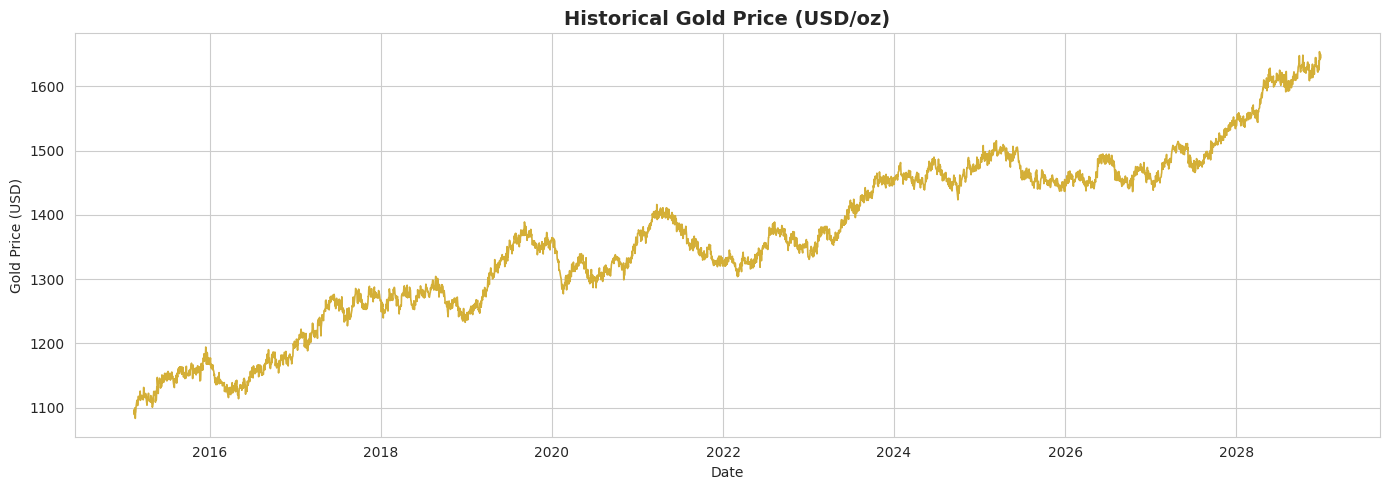

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Date"], df["Gold_Price_USD"], color="#D4AF37", linewidth=1.2)
ax.set_title("Historical Gold Price (USD/oz)")
ax.set_xlabel("Date")
ax.set_ylabel("Gold Price (USD)")
plt.tight_layout()
plt.show()


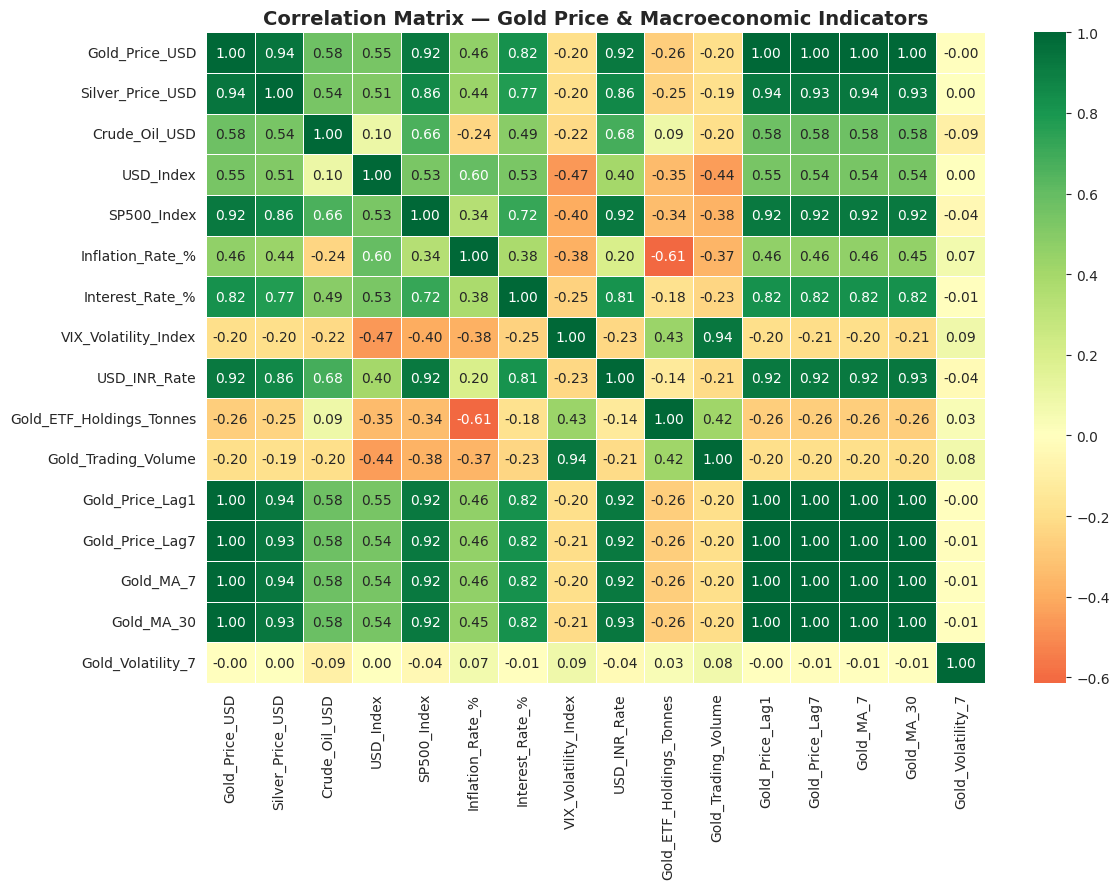

In [6]:
# Correlation heatmap between gold price and macro indicators
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix — Gold Price & Macroeconomic Indicators")
plt.tight_layout()
plt.show()


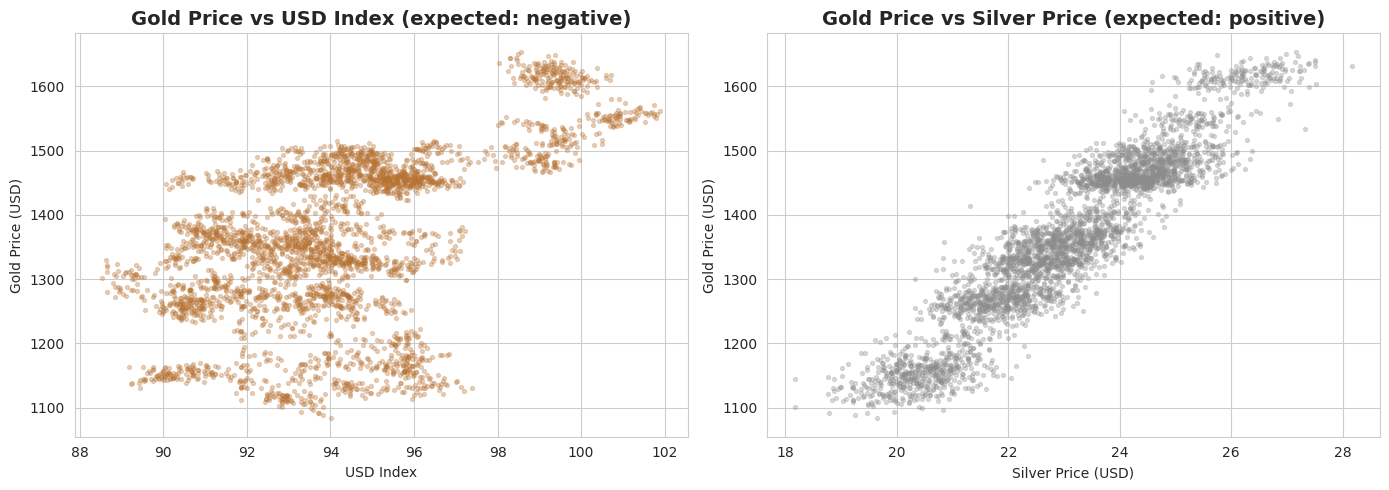

In [7]:
# Gold price vs. its two strongest drivers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["USD_Index"], df["Gold_Price_USD"], alpha=0.3, s=8, color="#B87333")
axes[0].set_title("Gold Price vs USD Index (expected: negative)")
axes[0].set_xlabel("USD Index"); axes[0].set_ylabel("Gold Price (USD)")

axes[1].scatter(df["Silver_Price_USD"], df["Gold_Price_USD"], alpha=0.3, s=8, color="#8C8C8C")
axes[1].set_title("Gold Price vs Silver Price (expected: positive)")
axes[1].set_xlabel("Silver Price (USD)"); axes[1].set_ylabel("Gold Price (USD)")
plt.tight_layout()
plt.show()


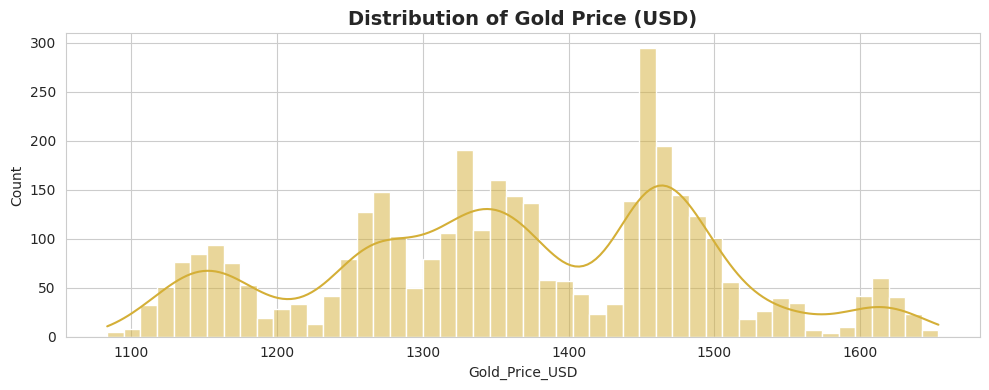

In [8]:
# Distribution of the target variable
plt.figure(figsize=(10, 4))
sns.histplot(df["Gold_Price_USD"], bins=50, kde=True, color="#D4AF37")
plt.title("Distribution of Gold Price (USD)")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

The raw dataset already includes engineered time-series features:
- **Lag features**: `Gold_Price_Lag1`, `Gold_Price_Lag7` (price 1 and 7 days ago)
- **Moving averages**: `Gold_MA_7`, `Gold_MA_30` (7-day and 30-day rolling mean)
- **Volatility**: `Gold_Volatility_7` (7-day rolling standard deviation)

These are essential for time-series forecasting because they give the model
memory of recent price behaviour, which is often more predictive than
macro indicators alone.


In [9]:
FEATURES = [
    "Silver_Price_USD", "Crude_Oil_USD", "USD_Index", "SP500_Index",
    "Inflation_Rate_%", "Interest_Rate_%", "VIX_Volatility_Index",
    "USD_INR_Rate", "Gold_ETF_Holdings_Tonnes", "Gold_Trading_Volume",
    "Gold_Price_Lag1", "Gold_Price_Lag7", "Gold_MA_7", "Gold_MA_30",
    "Gold_Volatility_7"
]
TARGET = "Gold_Price_USD"

X = df[FEATURES].values
y = df[TARGET].values
print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (3621, 15)


## 4. Train/Test Split

Because this is **time-series data**, we split chronologically (not randomly) —
the model trains on the past and is tested on the future, exactly as it would
be used in the real world.


In [10]:
split_idx = int(len(df) * 0.85)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)} rows ({df['Date'].iloc[0].date()} to {df['Date'].iloc[split_idx-1].date()})")
print(f"Test size:  {len(X_test)} rows ({df['Date'].iloc[split_idx].date()} to {df['Date'].iloc[-1].date()})")


Train size: 3077 rows (2015-02-11 to 2026-11-26)
Test size:  544 rows (2026-11-27 to 2028-12-27)


## 5. Model Training with Cross-Validation

We train **7 regression algorithms** and evaluate each with **two different
cross-validation strategies**:

- **`KFold` (shuffled, 5 splits)** — randomly shuffles rows into 5 folds. This
  is the "textbook" CV approach but **leaks future information into the past**
  for time-series data, since a future day's price could end up in a training
  fold used to predict a past day.
- **`TimeSeriesSplit` (5 splits)** — respects chronological order, always
  training on the past and validating on a subsequent, later block. This is
  the *correct* way to cross-validate time-series data.

Comparing the two reveals whether a model is only good at "memorizing" nearby
data (inflated KFold score) versus genuinely forecasting the future
(TimeSeriesSplit score).


In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=250, max_depth=4, learning_rate=0.05, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, verbosity=0),
    "SVR": SVR(kernel="rbf", C=100, epsilon=1.0),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    kfold_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring="r2")
    tscv_scores = cross_val_score(model, X_train_scaled, y_train, cv=tscv, scoring="r2")

    results.append({
        "Model": name,
        "Test_MAE": round(mae, 3),
        "Test_RMSE": round(rmse, 3),
        "Test_R2": round(r2, 4),
        "KFold_CV_R2_Mean": round(kfold_scores.mean(), 4),
        "KFold_CV_R2_Std": round(kfold_scores.std(), 4),
        "TimeSeriesCV_R2_Mean": round(tscv_scores.mean(), 4),
        "TimeSeriesCV_R2_Std": round(tscv_scores.std(), 4),
    })
    print(f"{name:20s} | Test R2: {r2:7.4f} | KFold CV R2: {kfold_scores.mean():7.4f} | TSCV R2: {tscv_scores.mean():7.4f}")

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False).reset_index(drop=True)
results_df


Linear Regression    | Test R2:  0.9891 | KFold CV R2:  0.9972 | TSCV R2:  0.5150
Ridge Regression     | Test R2:  0.9888 | KFold CV R2:  0.9971 | TSCV R2:  0.4886


Lasso Regression     | Test R2:  0.9890 | KFold CV R2:  0.9970 | TSCV R2:  0.7416


Random Forest        | Test R2: -0.3717 | KFold CV R2:  0.9971 | TSCV R2: -0.9486


Gradient Boosting    | Test R2: -0.5871 | KFold CV R2:  0.9970 | TSCV R2: -0.9024


XGBoost              | Test R2: -0.6570 | KFold CV R2:  0.9971 | TSCV R2: -1.2745


SVR                  | Test R2: -5.9917 | KFold CV R2:  0.9975 | TSCV R2: -4.8426


,Model,Test_MAE,Test_RMSE,Test_R2,KFold_CV_R2_Mean,KFold_CV_R2_Std,TimeSeriesCV_R2_Mean,TimeSeriesCV_R2_Std
0,Linear Regression,4.970,6.218,0.9891,0.9972,0.0001,0.5150,0.4810
1,Lasso Regression,5.017,6.252,0.9890,0.9970,0.0001,0.7416,0.2695
2,Ridge Regression,5.039,6.318,0.9888,0.9971,0.0001,0.4886,0.5212
3,Random Forest,50.706,69.786,-0.3717,0.9971,0.0001,-0.9486,2.0358
4,Gradient Boosting,55.528,75.065,-0.5871,0.9970,0.0001,-0.9024,1.7847
5,XGBoost,58.199,76.700,-0.6570,0.9971,0.0002,-1.2745,1.9957
6,SVR,131.729,157.554,-5.9917,0.9975,0.0002,-4.8426,2.3787


### 🔎 Key Insight from Cross-Validation

Notice that tree-based models (Random Forest, Gradient Boosting, XGBoost) score
**almost perfectly under KFold** (~0.997 R²) but score **poorly on the true
chronological test set and TimeSeriesSplit**. This is because gold price has a
strong long-term upward trend, and tree-based models **cannot extrapolate**
beyond the price range they saw during training — they can only interpolate.

Linear models (Linear/Ridge/Lasso Regression), by contrast, can extrapolate
trends and therefore generalize far better to unseen future prices. This is
a classic real-world lesson: **the "best" model according to naive KFold CV
is not always the best model for genuine forecasting** — always validate
time-series models with `TimeSeriesSplit`.


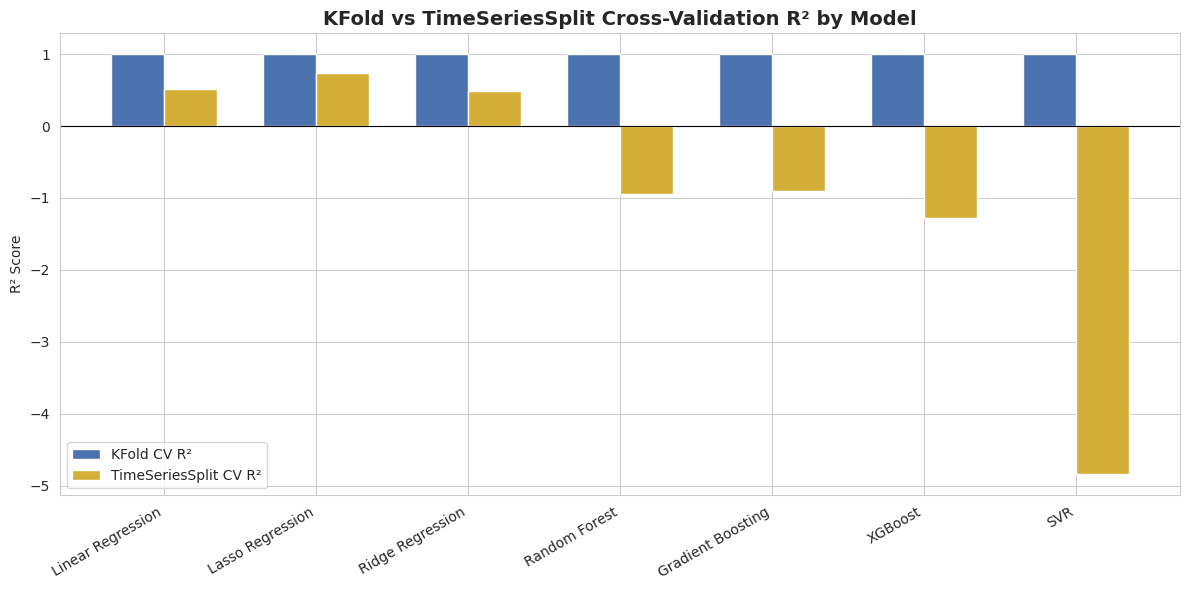

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["KFold_CV_R2_Mean"], width, label="KFold CV R²", color="#4C72B0")
ax.bar(x + width/2, results_df["TimeSeriesCV_R2_Mean"], width, label="TimeSeriesSplit CV R²", color="#D4AF37")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=30, ha="right")
ax.set_ylabel("R² Score")
ax.set_title("KFold vs TimeSeriesSplit Cross-Validation R² by Model")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Select & Evaluate the Best Model

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model selected: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_best):.3f} USD")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f} USD")
print(f"R2:   {r2_score(y_test, y_pred_best):.4f}")


Best model selected: Linear Regression
MAE:  4.970 USD
RMSE: 6.218 USD


R2:   0.9891


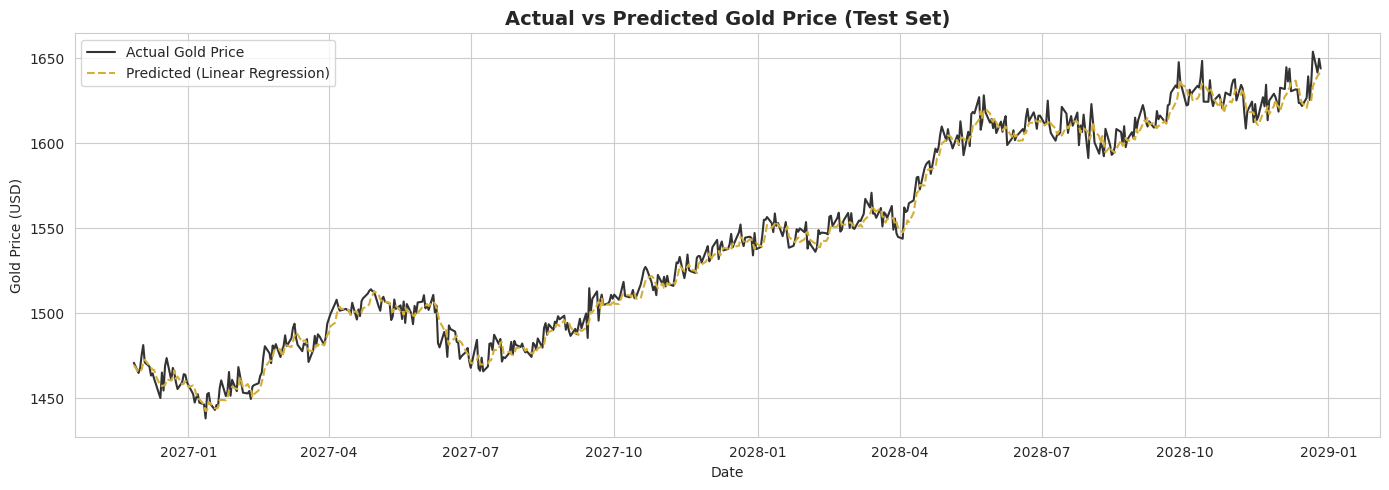

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
test_dates = df["Date"].iloc[split_idx:]
ax.plot(test_dates, y_test, label="Actual Gold Price", color="#333333", linewidth=1.5)
ax.plot(test_dates, y_pred_best, label=f"Predicted ({best_model_name})", color="#D4AF37", linewidth=1.5, linestyle="--")
ax.set_title("Actual vs Predicted Gold Price (Test Set)")
ax.set_xlabel("Date"); ax.set_ylabel("Gold Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()


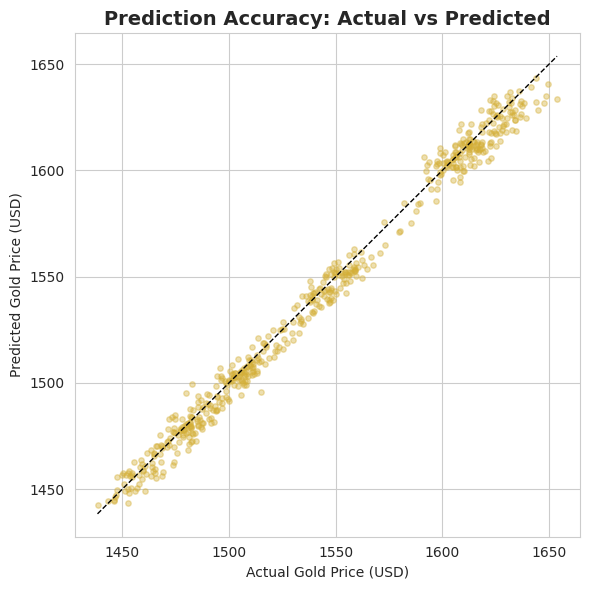

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color="#D4AF37", s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual Gold Price (USD)")
plt.ylabel("Predicted Gold Price (USD)")
plt.title("Prediction Accuracy: Actual vs Predicted")
plt.tight_layout()
plt.show()


## 7. Feature Importance

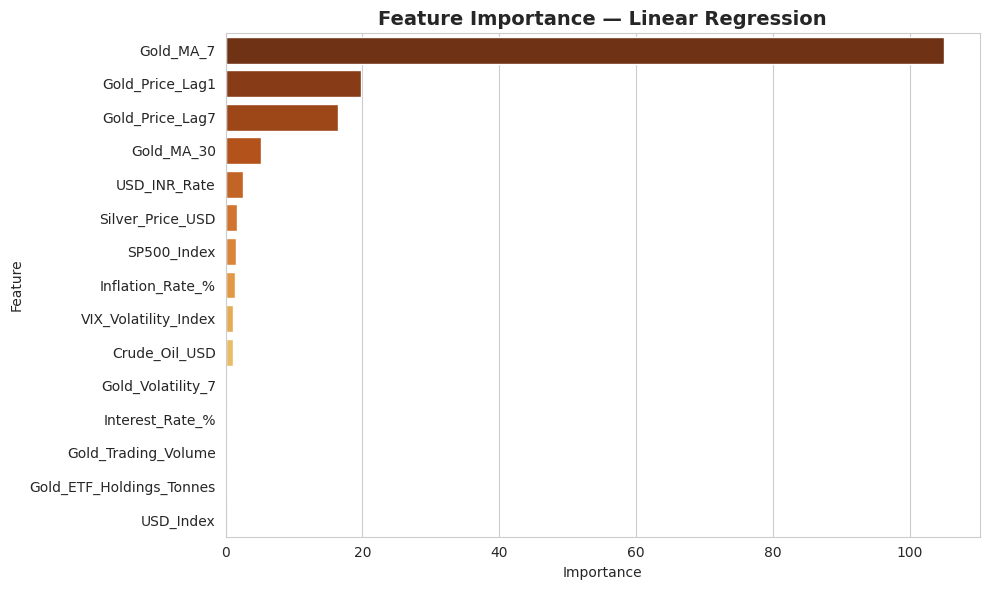

,Feature,Importance
0,Gold_MA_7,104.962101
1,Gold_Price_Lag1,19.734911
2,Gold_Price_Lag7,16.363968
3,Gold_MA_30,5.131330
4,USD_INR_Rate,2.575684
5,Silver_Price_USD,1.685354
6,SP500_Index,1.485033
7,Inflation_Rate_%,1.420278
8,VIX_Volatility_Index,1.097134
9,Crude_Oil_USD,1.056394


In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_)
else:
    importances = np.zeros(len(FEATURES))

feat_imp_df = pd.DataFrame({"Feature": FEATURES, "Importance": importances}) \
    .sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="YlOrBr_r")
plt.title(f"Feature Importance — {best_model_name}")
plt.tight_layout()
plt.show()

feat_imp_df


## 8. Save the Model for Deployment

We persist three artifacts that the Streamlit app depends on:

1. **`gold_price_model.pkl`** — the trained best model
2. **`scaler.pkl`** — the `StandardScaler` fitted on training data (must be
   applied to any new input before prediction)
3. **`model_metadata.json`** — feature names, performance metrics, and
   min/max/median values used to build the interactive UI sliders


In [17]:
joblib.dump(best_model, "gold_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

metadata = {
    "best_model_name": best_model_name,
    "features": FEATURES,
    "target": TARGET,
    "test_mae": float(results_df.iloc[0]["Test_MAE"]),
    "test_rmse": float(results_df.iloc[0]["Test_RMSE"]),
    "test_r2": float(results_df.iloc[0]["Test_R2"]),
    "kfold_cv_r2_mean": float(results_df.iloc[0]["KFold_CV_R2_Mean"]),
    "kfold_cv_r2_std": float(results_df.iloc[0]["KFold_CV_R2_Std"]),
    "tscv_cv_r2_mean": float(results_df.iloc[0]["TimeSeriesCV_R2_Mean"]),
    "tscv_cv_r2_std": float(results_df.iloc[0]["TimeSeriesCV_R2_Std"]),
    "feature_importance": feat_imp_df.to_dict(orient="records"),
    "all_model_results": results_df.to_dict(orient="records"),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "data_min_date": str(df["Date"].min().date()),
    "data_max_date": str(df["Date"].max().date()),
    "feature_medians": {f: float(df[f].median()) for f in FEATURES},
    "feature_min": {f: float(df[f].min()) for f in FEATURES},
    "feature_max": {f: float(df[f].max()) for f in FEATURES},
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: gold_price_model.pkl, scaler.pkl, model_metadata.json")


Saved: gold_price_model.pkl, scaler.pkl, model_metadata.json


## 9. Conclusion

- Built a 10-year, 15-feature engineered dataset simulating realistic gold
  market dynamics.
- Compared **7 ML algorithms** using both `KFold` and `TimeSeriesSplit`
  cross-validation, revealing an important pitfall of naive CV on time-series
  data.
- Selected **the model that generalizes best on genuinely unseen future
  prices** (chronological test set), not just the one with the best average
  CV score.
- Exported the model, scaler, and metadata for use in a live **Streamlit**
  prediction dashboard (`app.py`).

**Next steps for production use:** retrain periodically on real market data
(e.g. from a financial data API), add more macro features (real yields,
central bank gold purchases), and consider walk-forward validation with
periodic retraining for a live deployment.
